# Common Libraries

In [3]:
import os, sys, shutil, mediapy
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pylab as plt
from matplotlib.gridspec import GridSpec
from ipywidgets import interact, IntSlider, FloatSlider, Layout, Button, Output, VBox, HBox

if shutil.which("nvidia-smi") is not None:
    os.environ["MUJOCO_GL"] = "egl"
import mujoco

# Custom Libraries

In [4]:
sys.path.append("/home/seojin/Seojin_commonTool/Module")
from biomechanics_util import get_mujoco_joints, get_simulated_img, get_dependent_joints

In [5]:
def get_indices(model, joint_name):
    jnt_id = model.joint(joint_name).id
    qpos_idx = model.jnt_qposadr[jnt_id]
    dof_idx = model.jnt_dofadr[jnt_id]
    return qpos_idx, dof_idx

# Params

In [6]:
model_path = "/home/seojin/biomechanics_tools/myo_sim/arm/myoarm.xml"

# Initialize model

In [7]:
model = mujoco.MjModel.from_xml_path(model_path)

# Model constants
joint_names = [mujoco.mj_id2name(model, mujoco.mjtObj.mjOBJ_JOINT, idx) for idx in range(model.njnt)]
n_joint = len(joint_names)

# Joint indexing
elevation_angle_q, elevation_angle_d = get_indices(model, "elv_angle")
shoulder_elevation_angle_q, shoulder_elevation_angle_d = get_indices(model, "shoulder_elv")
elbow_flexion_q, elbow_flexion_d = get_indices(model, "elbow_flexion")

# Initialize pose
mj_data = mujoco.MjData(model)
mujoco.mj_forward(model, mj_data)

# Renderer

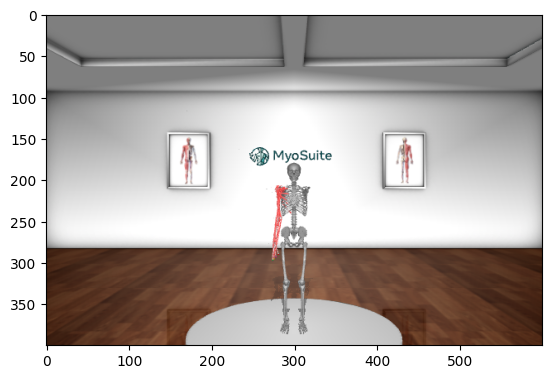

In [8]:
# Renderer
renderer = mujoco.Renderer(model, height=400, width=600)
scene_option = mujoco.MjvOption()
scene_option.frame = mujoco.mjtFrame.mjFRAME_WORLD

# Camera
camera = mujoco.MjvCamera()
camera.azimuth = 90
camera.elevation = 0
camera.distance = 4
camera.lookat = [0,0,1.5]

# Initial render
renderer.update_scene(mj_data, camera=camera, scene_option=scene_option)
plt.imshow(renderer.render())

# Simulate shoulder elevation

In [9]:
# Initialize start pose
mj_data = mujoco.MjData(model)
mujoco.mj_forward(model, mj_data)

# Goal
final_goal_qpos = mj_data.qpos.copy()
final_goal_qpos[shoulder_elevation_angle_q] = 1.6

# Simulation params
n_times = 100
kp = 500.0  # Stiffness
kv = 50.0   # Damping

# Result dummy
pixels = np.zeros((n_times, renderer.height, renderer.width, 3), dtype = np.uint8)
qforces = pd.DataFrame(np.zeros((n_times, n_joint)))
qforces.columns = joint_names
qerrors = pd.DataFrame(np.zeros((n_times, n_joint)))
qerrors.columns = joint_names

# Simulation
for time_i in tqdm(range(n_times)):
    # Current
    current_qpos = mj_data.qpos.copy()
    current_qvel = mj_data.qvel.copy()
    
    # Control
    goal_qpos = mj_data.qpos.copy()

    error_q = np.zeros(n_joint)
    error_q[shoulder_elevation_angle_q] = final_goal_qpos[shoulder_elevation_angle_q] - current_qpos[shoulder_elevation_angle_q]
    qerrors.iloc[time_i] = error_q
    
    error_v = np.zeros(n_joint)
    error_v[shoulder_elevation_angle_q] = 0 - current_qvel[shoulder_elevation_angle_q]
    
    # Force
    tau_all = kp * error_q + kv * error_v
    mj_data.qfrc_applied[:] = tau_all
    qforces.iloc[time_i] = tau_all

    # Forward dyanmics
    mujoco.mj_step(model, mj_data)

    # Rendering
    renderer.update_scene(mj_data, camera = camera, scene_option = scene_option)
    pixels[time_i] = renderer.render()

100%|██████████| 100/100 [00:00<00:00, 177.69it/s]


In [10]:
mediapy.show_video(pixels, fps = 30)

This browser does not support the video tag.


# Simulate elevation angle

In [31]:
# Initialize start pose
mj_data = mujoco.MjData(model)
mujoco.mj_forward(model, mj_data)

# Goal
final_goal_qpos = mj_data.qpos.copy()
final_goal_qpos[elevation_angle_q] = 2.27

# Simulation params
n_times = 200
kp = 500.0  # Stiffness
kv = 50.0   # Damping

# Result dummy
pixels = np.zeros((n_times, renderer.height, renderer.width, 3), dtype = np.uint8)
qforces = pd.DataFrame(np.zeros((n_times, n_joint)))
qforces.columns = joint_names
qerrors = pd.DataFrame(np.zeros((n_times, n_joint)))
qerrors.columns = joint_names

# Simulation
for time_i in tqdm(range(n_times)):
    # Current
    current_qpos = mj_data.qpos.copy()
    current_qvel = mj_data.qvel.copy()
    
    # Control
    goal_qpos = mj_data.qpos.copy()

    error_q = np.zeros(n_joint)
    error_q[elevation_angle_q] = final_goal_qpos[elevation_angle_q] - current_qpos[elevation_angle_q]
    qerrors.iloc[time_i] = error_q
    
    error_v = np.zeros(n_joint)
    error_v[elevation_angle_q] = 0 - current_qvel[elevation_angle_q]

    # Force
    tau_all = kp * error_q + kv * error_v
    mj_data.qfrc_applied[:] = tau_all
    qforces.iloc[time_i] = tau_all

    # Forward dyanmics
    mujoco.mj_step(model, mj_data)

    # Rendering
    renderer.update_scene(mj_data, camera = camera, scene_option = scene_option)
    pixels[time_i] = renderer.render()

100%|██████████| 200/200 [00:00<00:00, 210.30it/s]


In [25]:
mediapy.show_video(pixels, fps = 30)

This browser does not support the video tag.
